# Activation Functions

Activation functions add **non-linearity** so neural networks can learn complex patterns.

**Covered:** Sigmoid, Tanh, ReLU, Leaky ReLU, PReLU, ELU, GELU, SiLU, Mish, Hard Sigmoid, Hard Swish, Hard Tanh, GLU.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

x = np.linspace(-6, 6, 1000)

def plot_activation(x, y, title, ylim=None):
    plt.figure(figsize=(8, 4.5))
    plt.plot(x, y, linewidth=2)
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.grid(True, alpha=0.25)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    if ylim:
        plt.ylim(*ylim)
    plt.show()


In [ ]:
def plot_activation_and_derivative(x, y, dy, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(x, y, linewidth=2)
    ax[0].axhline(0, linewidth=0.8)
    ax[0].axvline(0, linewidth=0.8)
    ax[0].grid(True, alpha=0.25)
    ax[0].set_title(title)
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("f(x)")

    ax[1].plot(x, dy, linewidth=2)
    ax[1].axhline(0, linewidth=0.8)
    ax[1].axvline(0, linewidth=0.8)
    ax[1].grid(True, alpha=0.25)
    ax[1].set_title(title + " — derivative")
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("f'(x)")
    plt.tight_layout()
    plt.show()


## 1. Sigmoid

**Definition:** Converts a value to a number between 0 and 1.

**Easy idea:** Think of it like a dimmer switch: it turns any number into a value between 0 and 1.

**Formula:**
$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

**Derivative:**
$$
\sigma'(x)=\sigma(x)(1-\sigma(x))
$$

**Worked derivative example:** At $x=0$:
$$\sigma(0)=0.5$$
$$\sigma'(0)=0.5(1-0.5)=0.25$$

**Example use:** Binary classification output layer.


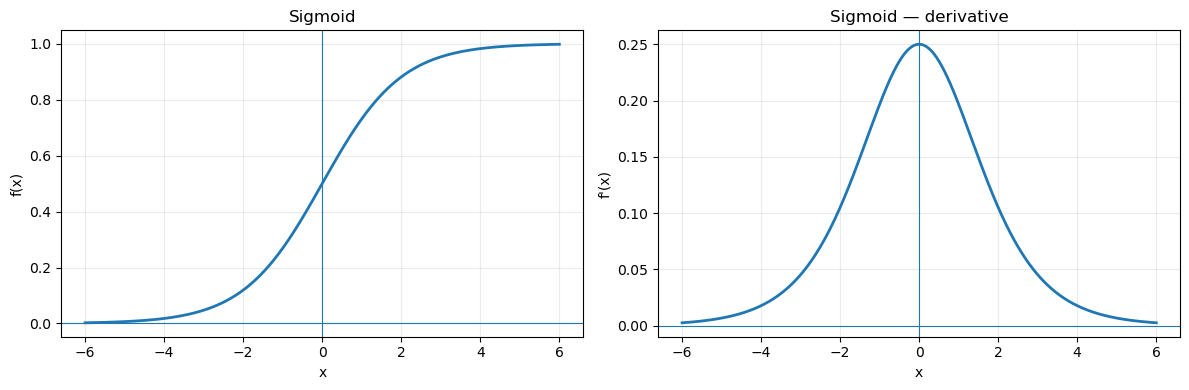

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


plot_activation_and_derivative(x, sigmoid(x), sigmoid_derivative(x), "Sigmoid")


## 2. Tanh

**Definition:** Maps values to the range -1 to +1 and is zero-centered.

**Easy idea:** Think of it like a balance scale: negative values go toward -1, positive values go toward +1, and zero stays at zero.

**Formula:**
$$
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}
$$

**Derivative:**
$$
\tanh'(x)=1-\tanh^2(x)
$$

**Worked derivative example:** At $x=1$:
$$\tanh(1)\approx0.7616$$
$$\tanh'(1)=1-(0.7616)^2\approx0.4200$$

**Example use:** Recurrent neural networks and gates.


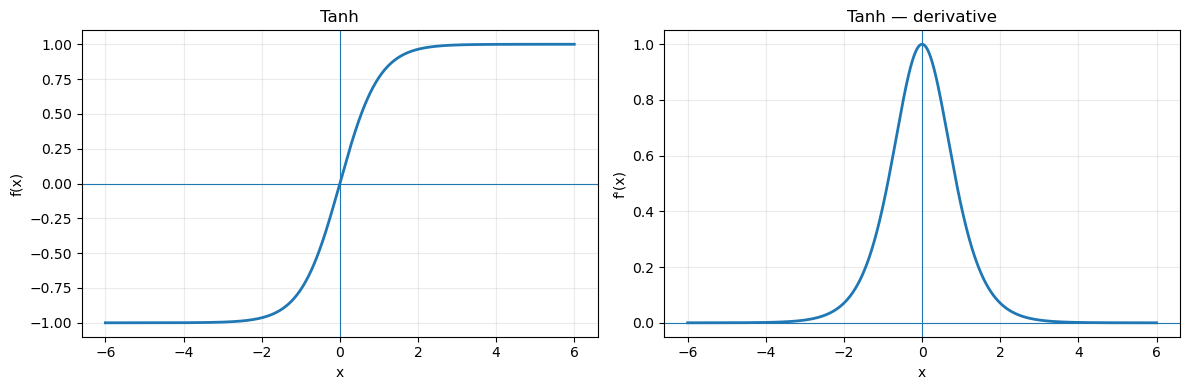

In [ ]:
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    t = tanh(x)
    return 1 - t**2


plot_activation_and_derivative(x, tanh(x), tanh_derivative(x), "Tanh")


## 3. ReLU

**Definition:** Keeps positive values and changes negative values to zero.

**Easy idea:** Think of it like a gate: positive numbers pass through, while negative numbers are stopped at zero.

**Formula:**
$$
f(x)=\max(0,x)
$$

**Derivative:**
$$
f'(x)=
\begin{cases}
0,&x<0\\
1,&x>0
\end{cases}
$$

At $x=0$, the derivative is undefined; implementations choose a convention.

**Worked derivative example:** At $x=2$:
$$f(2)=2,\quad f'(2)=1$$

At $x=-2$:
$$f(-2)=0,\quad f'(-2)=0$$

**Example use:** Standard hidden-layer activation in CNNs and MLPs.


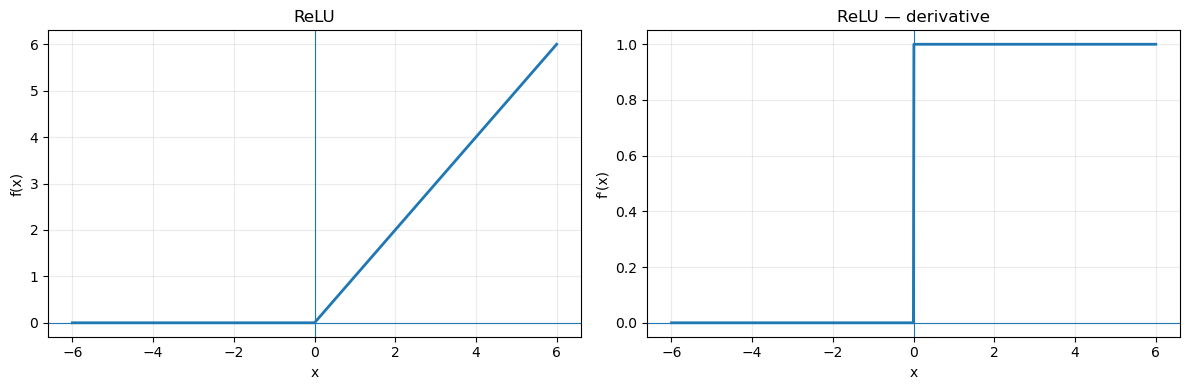

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)


plot_activation_and_derivative(x, relu(x), relu_derivative(x), "ReLU")


## 4. Leaky ReLU

**Definition:** ReLU with a small negative slope, so negative inputs still have a gradient.

**Easy idea:** It is a ReLU gate with a tiny opening on the negative side, so a little information can still pass.

**Formula:**
$$
f(x)=
\begin{cases}
x,&x\ge0\\
\alpha x,&x<0
\end{cases}
$$

Usually $\alpha=0.01$.

**Derivative:**
$$
f'(x)=
\begin{cases}
1,&x>0\\
\alpha,&x<0
\end{cases}
$$

**Worked derivative example:** For $\alpha=0.01$ and $x=-3$:
$$f(-3)=0.01(-3)=-0.03$$
$$f'(-3)=0.01$$

**Example use:** Hidden layers when avoiding dead ReLU (Neuron Permanently inactive) neurons is important.


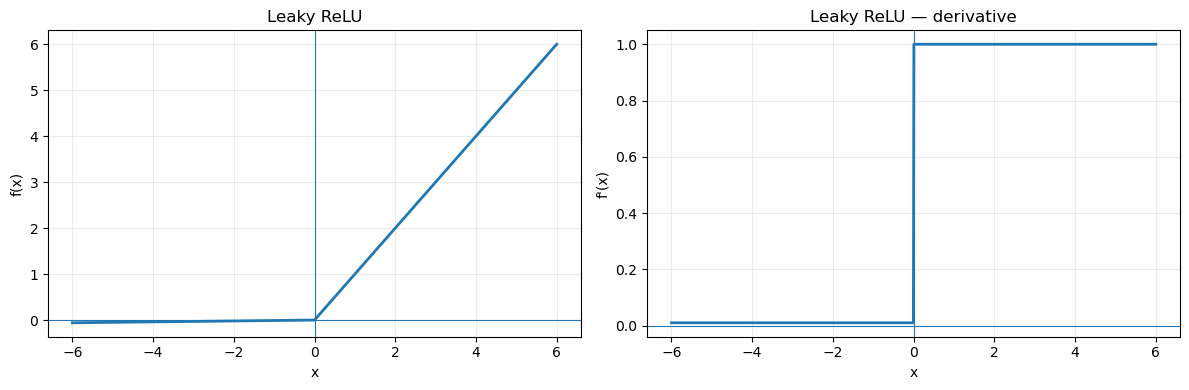

In [ ]:
def leaky_relu(x, alpha=0.01):
    return np.where(x >= 0, x, alpha * x)

def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1.0, alpha)


plot_activation_and_derivative(x, leaky_relu(x), leaky_relu_derivative(x), "Leaky ReLU")


## 5. Parametric ReLU (PReLU)

**Definition:** Leaky ReLU where the negative slope $\alpha$ is learned during training.

**Easy idea:** Instead of choosing the negative slope yourself, the model learns it.

**Formula:**
$$
f(x)=
\begin{cases}
x,&x\ge0\\
\alpha x,&x<0
\end{cases}
$$

**Derivative with respect to $x$:**
$$
\frac{\partial f}{\partial x}=
\begin{cases}
1,&x>0\\
\alpha,&x<0
\end{cases}
$$

**Derivative with respect to $\alpha$:**
$$
\frac{\partial f}{\partial\alpha}=
\begin{cases}
0,&x\ge0\\
x,&x<0
\end{cases}
$$

**Worked derivative example:** If $x=-2$ and $\alpha=0.25$:
$$f(-2)=0.25(-2)=-0.5$$
$$\frac{\partial f}{\partial x}=0.25$$
$$\frac{\partial f}{\partial\alpha}=-2$$

**Example use:** CNNs where a learned negative slope can improve feature learning.


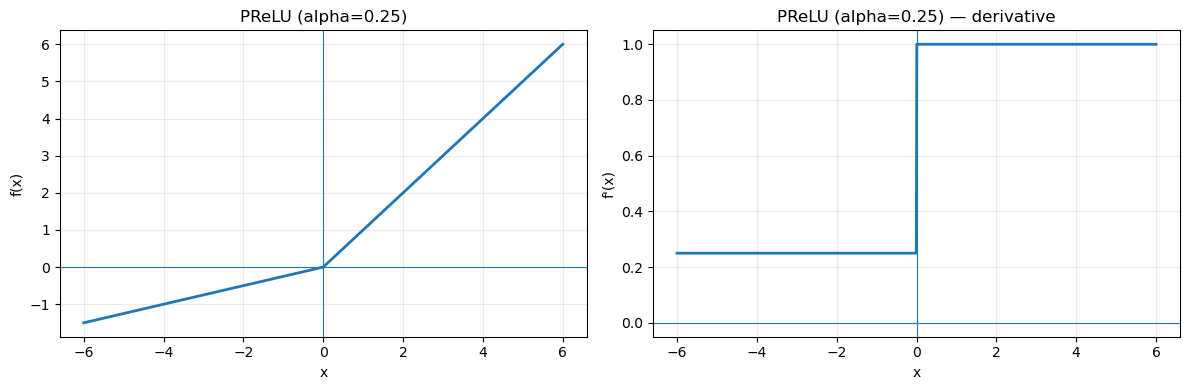

In [ ]:
def prelu(x, alpha=0.25):
    return np.where(x >= 0, x, alpha * x)

def prelu_derivative(x, alpha=0.25):
    return np.where(x > 0, 1.0, alpha)

plot_activation_and_derivative(x, prelu(x), prelu_derivative(x), "PReLU (alpha=0.25)")


## 6. Exponential Linear Unit (ELU)

**Definition:** ReLU-like activation with a smooth negative region.

**Easy idea:** It lets positive numbers pass normally and smoothly bends negative numbers instead of cutting them off.

**Formula:**
$$
f(x)=
\begin{cases}
x,&x>0\\
\alpha(e^x-1),&x\le0
\end{cases}
$$

**Derivative:**
$$
f'(x)=
\begin{cases}
1,&x>0\\
\alpha e^x,&x\le0
\end{cases}
$$

**Worked derivative example:** For $\alpha=1$ and $x=-1$:
$$f'(-1)=e^{-1}\approx0.3679$$

**Example use:** Deep networks where smoother negative behavior is useful.


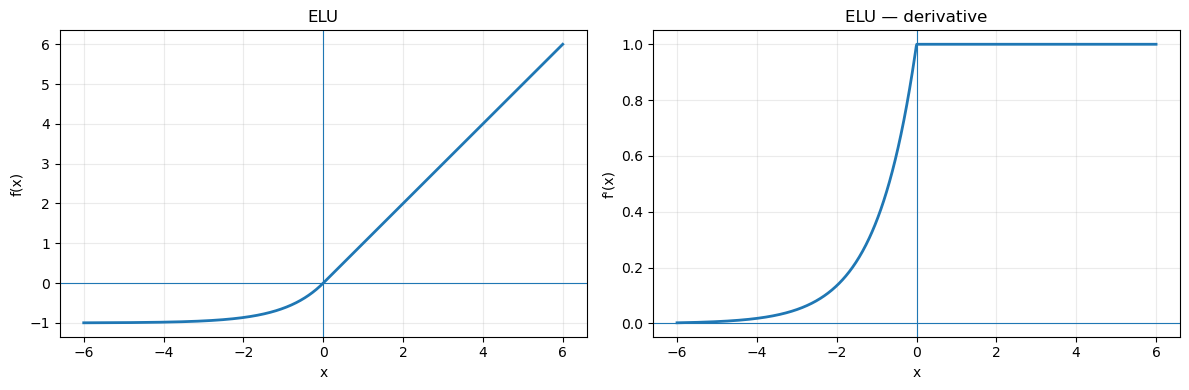

In [ ]:
def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def elu_derivative(x, alpha=1.0):
    return np.where(x > 0, 1.0, alpha * np.exp(x))


plot_activation_and_derivative(x, elu(x), elu_derivative(x), "ELU")


## 7. GELU — Gaussian Error Linear Unit

**Definition:** Smoothly weights inputs using their probability under a Gaussian distribution.

**Easy idea:** It is a soft gate: instead of suddenly keeping or removing a value, it smoothly decides how much of it should pass.

**Formula:**
$$
\operatorname{GELU}(x)=x\Phi(x)
$$
where $\Phi(x)$ is the standard normal CDF(Cumulative Distribution Function).

A common approximation is:
$$
\operatorname{GELU}(x)\approx
\frac{x}{2}\left[1+\tanh\left(\sqrt{\frac{2}{\pi}}(x+0.044715x^3)\right)\right]
$$

**Derivative of the exact form:**
$$
\operatorname{GELU}'(x)=\Phi(x)+x\phi(x)
$$
where $\phi(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2}$.

**Worked derivative example:** At $x=0$:
$$\Phi(0)=0.5,\quad \phi(0)=\frac{1}{\sqrt{2\pi}}\approx0.3989$$
$$\operatorname{GELU}'(0)=0.5+0(0.3989)=0.5$$

**Example use:** Transformer architectures, including BERT-style models.


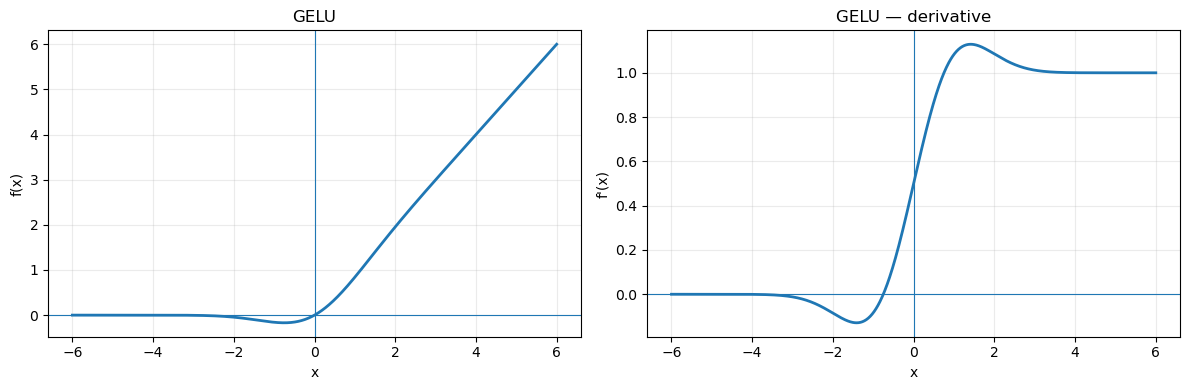

In [ ]:
def gelu(x):
    # Exact GELU using the normal CDF via erf
    return 0.5 * x * (1 + np.vectorize(math.erf)(x / np.sqrt(2)))

def gelu_derivative(x):
    phi = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)
    Phi = 0.5 * (1 + np.vectorize(math.erf)(x / np.sqrt(2)))
    return Phi + x * phi


plot_activation_and_derivative(x, gelu(x), gelu_derivative(x), "GELU")


## 8. SiLU / Swish

**Definition:** Multiplies the input by its sigmoid gate.

**Easy idea:** It lets a number control its own gate, so each value decides how much of itself should pass.

**Formula:**
$$
f(x)=x\sigma(x)
$$

**Derivative:**
$$
f'(x)=\sigma(x)+x\sigma(x)(1-\sigma(x))
$$

**Worked derivative example:** At $x=1$:
$$\sigma(1)\approx0.7311$$
$$f'(1)=0.7311+1(0.7311)(1-0.7311)$$
$$f'(1)\approx0.9277$$

**Example use:** Modern CNNs and efficient vision models.


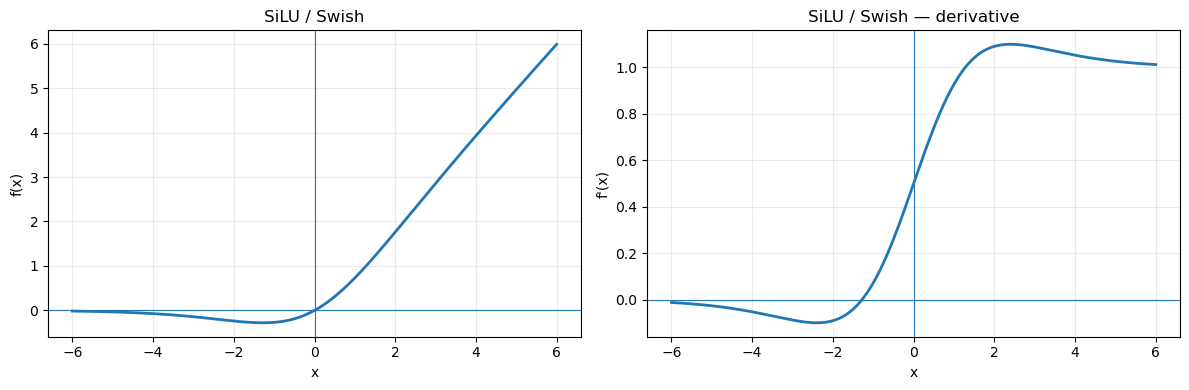

In [ ]:
def silu(x):
    return x * sigmoid(x)

def silu_derivative(x):
    s = sigmoid(x)
    return s + x * s * (1 - s)

plot_activation_and_derivative(x, silu(x), silu_derivative(x), "SiLU / Swish")


## 9. Mish

**Definition:** A smooth self-gated activation using softplus and tanh.

**Easy idea:** It is a smooth self-gate that gently decides how much of a number should pass.

**Formula:**
$$
f(x)=x\tanh(\operatorname{softplus}(x))
$$
where
$$
\operatorname{softplus}(x)=\ln(1+e^x)
$$

Let $s=\operatorname{softplus}(x)$ and $t=\tanh(s)$.

**Derivative:**
$$
f'(x)=t+x(1-t^2)\sigma(x)
$$

**Worked derivative example:** At $x=0$:
$$s=\ln2\approx0.6931$$
$$t=\tanh(0.6931)\approx0.6$$
$$\sigma(0)=0.5$$
$$f'(0)=0.6+0(1-0.6^2)(0.5)=0.6$$

**Example use:** Deep CNNs when a smooth non-monotonic activation is useful.


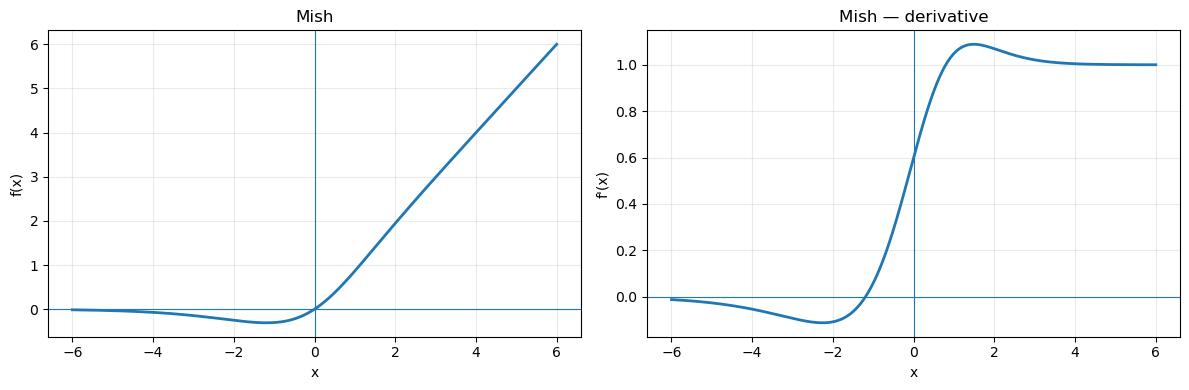

In [ ]:
def mish(x):
    softplus = np.logaddexp(0, x)
    return x * np.tanh(softplus)

def mish_derivative(x):
    s = np.logaddexp(0, x)
    t = np.tanh(s)
    return t + x * (1 - t**2) * sigmoid(x)


plot_activation_and_derivative(x, mish(x), mish_derivative(x), "Mish")


## 10. Hard Sigmoid

**Definition:** A piecewise-linear approximation of sigmoid.

**Easy idea:** It is a faster, simpler version of Sigmoid that uses straight lines instead of a smooth curve.

**Formula:**
$$
f(x)=
\begin{cases}
0,&x\le-2.5\\
0.2x+0.5,&-2.5<x<2.5\\
1,&x\ge2.5
\end{cases}
$$

**Derivative:**
$$
f'(x)=
\begin{cases}
0,&x<-2.5\\
0.2,&-2.5<x<2.5\\
0,&x>2.5
\end{cases}
$$

**Worked derivative example:** At $x=1$:
$$f(1)=0.2(1)+0.5=0.7$$
$$f'(1)=0.2$$

**Example use:** Mobile/edge models where cheaper computation is useful.


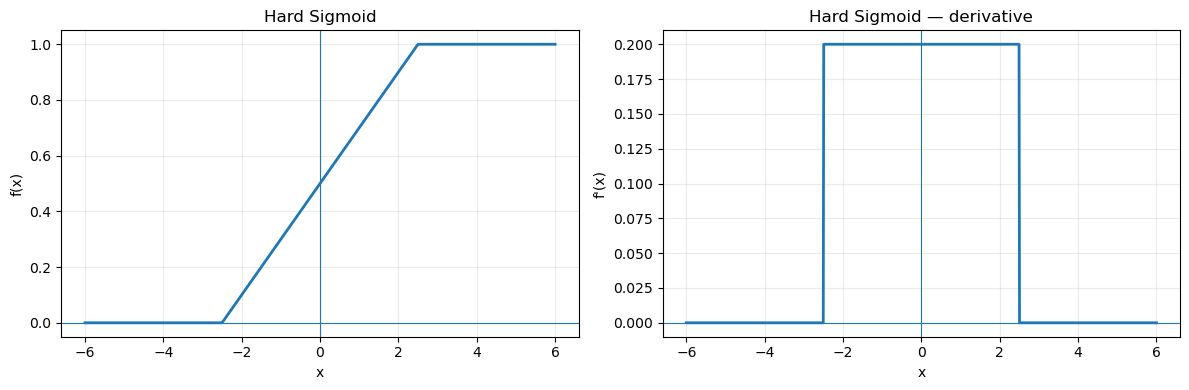

In [ ]:
def hard_sigmoid(x):
    return np.clip(0.2 * x + 0.5, 0, 1)

def hard_sigmoid_derivative(x):
    return np.where((x > -2.5) & (x < 2.5), 0.2, 0.0)


plot_activation_and_derivative(x, hard_sigmoid(x), hard_sigmoid_derivative(x), "Hard Sigmoid")


## 11. Hard Swish

**Definition:** A computationally cheaper approximation of SiLU.

**Easy idea:** It is a faster version of SiLU that replaces the smooth gate with a simple piecewise-linear gate.

**Formula:**
$$
f(x)=x\frac{\operatorname{HardSigmoid}(x)}{}
$$
or
$$
f(x)=x\frac{\operatorname{ReLU6}(x+3)}{6}
$$

Equivalent piecewise form:
$$
f(x)=
\begin{cases}
0,&x\le-3\\
\frac{x(x+3)}{6},&-3<x<3\\
x,&x\ge3
\end{cases}
$$

**Derivative:**
$$
f'(x)=
\begin{cases}
0,&x<-3\\
\frac{2x+3}{6},&-3<x<3\\
1,&x>3
\end{cases}
$$

**Worked derivative example:** At $x=1$:
$$f(1)=\frac{1(1+3)}{6}=\frac{4}{6}\approx0.6667$$
$$f'(1)=\frac{2(1)+3}{6}=\frac56\approx0.8333$$

**Example use:** MobileNetV3 and mobile/edge vision models.


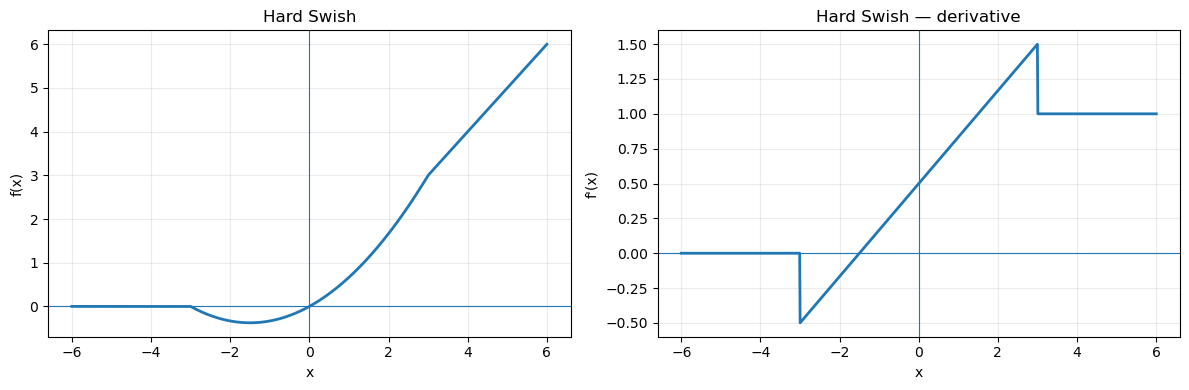

In [ ]:
def hard_swish(x):
    return x * np.clip(x + 3, 0, 6) / 6

def hard_swish_derivative(x):
    return np.where(x < -3, 0.0, np.where(x < 3, (2*x + 3)/6, 1.0))


plot_activation_and_derivative(x, hard_swish(x), hard_swish_derivative(x), "Hard Swish")


## 12. Hard Tanh

**Definition:** Clips the input to the range -1 to +1.

**Easy idea:** It is a number clamp: values below -1 become -1, values above +1 become +1, and values in between stay unchanged.

**Formula:**
$$
f(x)=
\begin{cases}
-1,&x\le-1\\
x,&-1<x<1\\
1,&x\ge1
\end{cases}
$$

**Derivative:**
$$
f'(x)=
\begin{cases}
0,&x<-1\\
1,&-1<x<1\\
0,&x>1
\end{cases}
$$

**Worked derivative example:** At $x=0.5$:
$$f(0.5)=0.5,\quad f'(0.5)=1$$

At $x=2$:
$$f(2)=1,\quad f'(2)=0$$

**Example use:** Quantized or resource-constrained neural networks.


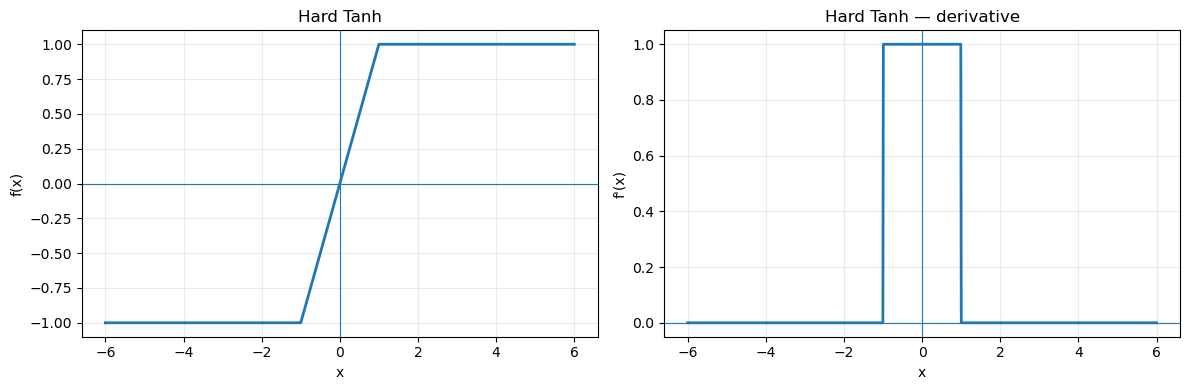

In [ ]:
def hard_tanh(x):
    return np.clip(x, -1, 1)

def hard_tanh_derivative(x):
    return np.where((x > -1) & (x < 1), 1.0, 0.0)

plot_activation_and_derivative(x, hard_tanh(x), hard_tanh_derivative(x), "Hard Tanh")


## 13. Gated Linear Unit (GLU)

**Definition:** Splits an input into two parts. One part carries values; the other creates a sigmoid gate.

**Easy idea:** Think of one value as the message and another as a gate that decides how much of the message gets through.

**Formula:**
$$
\operatorname{GLU}(a,b)=a\sigma(b)
$$

**Derivatives:**
$$
\frac{\partial \operatorname{GLU}}{\partial a}=\sigma(b)
$$

$$
\frac{\partial \operatorname{GLU}}{\partial b}
=a\sigma(b)(1-\sigma(b))
$$

**Worked derivative example:** Let $a=2$, $b=1$:
$$\sigma(1)\approx0.7311$$
$$\operatorname{GLU}(2,1)=2(0.7311)\approx1.4621$$

$$\frac{\partial GLU}{\partial a}=0.7311$$

$$\frac{\partial GLU}{\partial b}
=2(0.7311)(1-0.7311)\approx0.3932$$

**Example use:** Gated feed-forward layers in sequence and language models.

**Important:** GLU needs **two input tensors/chunks**, not one scalar input.


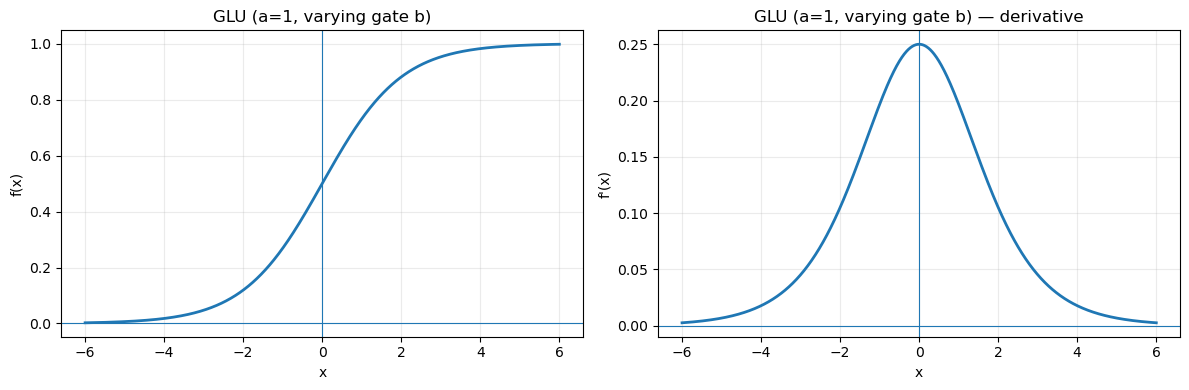

In [ ]:

def glu(a, b):
    return a * sigmoid(b)

def glu_derivative_wrt_b(a, b):
    s = sigmoid(b)
    return a * s * (1 - s)

b = np.linspace(-6, 6, 1000)
a = 1.0
plot_activation_and_derivative(
    b,
    glu(a, b),
    glu_derivative_wrt_b(a, b),
    "GLU (a=1, varying gate b)"
)


# All Activation Functions — Combined Graph

This graph makes the shape differences easy to compare.


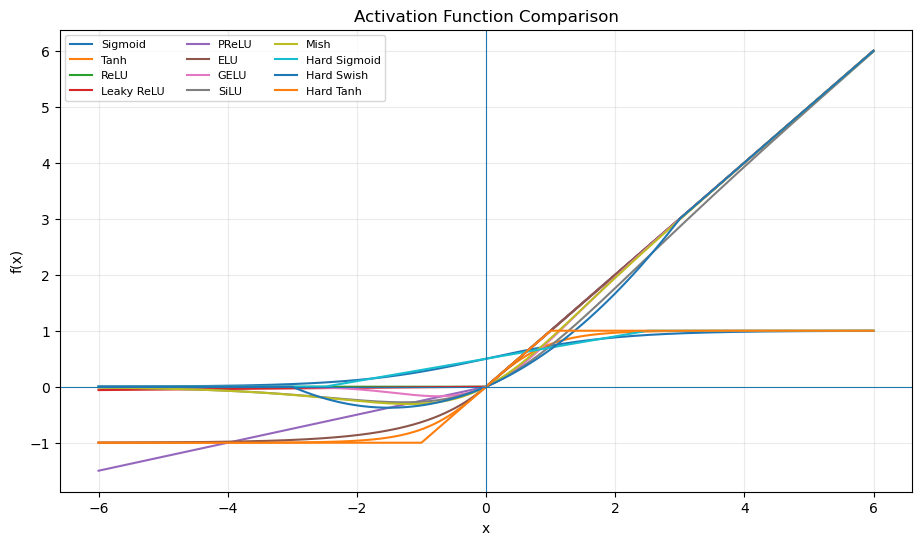

In [ ]:
plt.figure(figsize=(11, 6))
plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, tanh(x), label="Tanh")
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, leaky_relu(x), label="Leaky ReLU")
plt.plot(x, prelu(x), label="PReLU")
plt.plot(x, elu(x), label="ELU")
plt.plot(x, gelu(x), label="GELU")
plt.plot(x, silu(x), label="SiLU")
plt.plot(x, mish(x), label="Mish")
plt.plot(x, hard_sigmoid(x), label="Hard Sigmoid")
plt.plot(x, hard_swish(x), label="Hard Swish")
plt.plot(x, hard_tanh(x), label="Hard Tanh")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.grid(True, alpha=0.25)
plt.title("Activation Function Comparison")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend(ncol=3, fontsize=8)
plt.show()


# PyTorch Implementations

These are the standard library versions you will commonly use in neural networks.


In [ ]:
import torch
import torch.nn as nn

activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "Leaky ReLU": nn.LeakyReLU(negative_slope=0.01),
    "PReLU": nn.PReLU(num_parameters=1, init=0.25),
    "ELU": nn.ELU(alpha=1.0),
    "GELU": nn.GELU(),
    "SiLU": nn.SiLU(),
    "Hard Sigmoid": nn.Hardsigmoid(),
    "Hard Swish": nn.Hardswish(),
    "Hard Tanh": nn.Hardtanh(),
}

for name, activation in activations.items():
    print(f"{name:15} -> {activation}")


Sigmoid         -> Sigmoid()
Tanh            -> Tanh()
ReLU            -> ReLU()
Leaky ReLU      -> LeakyReLU(negative_slope=0.01)
PReLU           -> PReLU(num_parameters=1)
ELU             -> ELU(alpha=1.0)
GELU            -> GELU(approximate='none')
SiLU            -> SiLU()
Hard Sigmoid    -> Hardsigmoid()
Hard Swish      -> Hardswish()
Hard Tanh       -> Hardtanh(min_val=-1.0, max_val=1.0)


### GLU in PyTorch

`nn.GLU(dim=...)` splits the input into two equal parts and applies:

$$
GLU(a,b)=a\sigma(b)
$$


In [ ]:
x_glu = torch.tensor([[2.0, 1.0, 3.0, -1.0]])
glu_layer = nn.GLU(dim=1)

# Split into a=[2,1] and b=[3,-1]
print("Input:", x_glu)
print("GLU output:", glu_layer(x_glu))


Input: tensor([[ 2.,  1.,  3., -1.]])
GLU output: tensor([[1.9051, 0.2689]])


# Analytical vs Numerical Derivative

A finite-difference approximation can check whether our derivative formula is correct.

$$
f'(x)\approx\frac{f(x+h)-f(x-h)}{2h}
$$


In [ ]:
def numerical_derivative(func, x0, h=1e-5):
    return (func(x0 + h) - func(x0 - h)) / (2 * h)

checks = [
    ("Sigmoid", sigmoid, sigmoid_derivative),
    ("Tanh", tanh, tanh_derivative),
    ("ReLU", relu, relu_derivative),
    ("Leaky ReLU", leaky_relu, leaky_relu_derivative),
    ("PReLU", prelu, prelu_derivative),
    ("ELU", elu, elu_derivative),
    ("GELU", gelu, gelu_derivative),
    ("SiLU", silu, silu_derivative),
    ("Mish", mish, mish_derivative),
    ("Hard Sigmoid", hard_sigmoid, hard_sigmoid_derivative),
    ("Hard Swish", hard_swish, hard_swish_derivative),
    ("Hard Tanh", hard_tanh, hard_tanh_derivative),
]

test_x = 1.0

for name, func, deriv in checks:
    analytical = float(deriv(np.array(test_x)))
    numerical = float(numerical_derivative(func, test_x))
    print(f"{name:15} analytical={analytical:.6f}  numerical={numerical:.6f}")


Sigmoid         analytical=0.196612  numerical=0.196612
Tanh            analytical=0.419974  numerical=0.419974
ReLU            analytical=1.000000  numerical=1.000000
Leaky ReLU      analytical=1.000000  numerical=1.000000
PReLU           analytical=1.000000  numerical=1.000000
ELU             analytical=1.000000  numerical=1.000000
GELU            analytical=1.083315  numerical=1.083315
SiLU            analytical=0.927671  numerical=0.927671
Mish            analytical=1.049036  numerical=1.049036
Hard Sigmoid    analytical=0.200000  numerical=0.200000
Hard Swish      analytical=0.833333  numerical=0.833333
Hard Tanh       analytical=0.000000  numerical=0.500000


# Quick Comparison

| Function | Output behavior | Main idea | Typical use |
|---|---|---|---|
| Sigmoid | 0 to 1 | Probability/gate | Binary output |
| Tanh | -1 to 1 | Zero-centered | RNNs |
| ReLU | 0 to ∞ | Simple positive path | CNN/MLP hidden layers |
| Leaky ReLU | Negative slope | Avoid zero negative gradient | Hidden layers |
| PReLU | Learned negative slope | Learn the slope | CNNs |
| ELU | Smooth negative side | Better negative behavior | Deep networks |
| GELU | Smooth probabilistic gating | Soft input selection | Transformers |
| SiLU | $x\sigma(x)$ | Self-gating | CNNs |
| Mish | Smooth self-gating | Smooth + non-monotonic | CNNs |
| Hard Sigmoid | Piecewise 0 to 1 | Cheap sigmoid | Edge/mobile |
| Hard Swish | Piecewise SiLU | Cheap SiLU | MobileNetV3 |
| Hard Tanh | Clipping | Cheap bounded activation | Efficient/quantized models |
| GLU | Value × gate | Learnable gating | Language/sequence models |


# Which Activation Should You Choose?

| Situation | Good starting choice |
|---|---|
| Binary classification output | Sigmoid |
| Hidden layers in a simple CNN/MLP | ReLU |
| Dead ReLU concern | Leaky ReLU / PReLU |
| Smooth ReLU-like activation | ELU |
| Transformer feed-forward layers | GELU / SiLU |
| Modern vision networks | SiLU / Mish |
| Mobile / edge efficiency | Hard Swish |
| Bounded output from -1 to +1 | Tanh / Hard Tanh |
| Gated sequence or language layer | GLU |

There is no universal best activation. The architecture and task matter.


# Key Derivative Pattern

The derivative tells backpropagation **how strongly a neuron passes the gradient**.

- Derivative ≈ 0 → weak gradient
- Derivative ≈ 1 → strong gradient
- Negative-region slope in Leaky ReLU/PReLU → avoids a completely zero gradient
- Saturating functions such as Sigmoid/Tanh can produce very small gradients for large $|x|$
- Smooth functions such as GELU, SiLU, and Mish avoid the sharp ReLU corner


# Derivative Visualizations

The activation graph shows **what comes out**.

The derivative graph shows **how strongly the gradient can pass backward**.

Large derivative → stronger gradient flow.

Derivative near zero → weak gradient flow.
